In [1]:
!pip install transformers datasets av decord torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 70.0 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

from transformers import VivitForVideoClassification
from transformers import VivitImageProcessor

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [20]:
from transformers import VivitForVideoClassification

model_name = "google/vivit-b-16x2-kinetics400"

model = VivitForVideoClassification.from_pretrained(
    model_name
)

print(model.config.id2label)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7', 8: 'LABEL_8', 9: 'LABEL_9', 10: 'LABEL_10', 11: 'LABEL_11', 12: 'LABEL_12', 13: 'LABEL_13', 14: 'LABEL_14', 15: 'LABEL_15', 16: 'LABEL_16', 17: 'LABEL_17', 18: 'LABEL_18', 19: 'LABEL_19', 20: 'LABEL_20', 21: 'LABEL_21', 22: 'LABEL_22', 23: 'LABEL_23', 24: 'LABEL_24', 25: 'LABEL_25', 26: 'LABEL_26', 27: 'LABEL_27', 28: 'LABEL_28', 29: 'LABEL_29', 30: 'LABEL_30', 31: 'LABEL_31', 32: 'LABEL_32', 33: 'LABEL_33', 34: 'LABEL_34', 35: 'LABEL_35', 36: 'LABEL_36', 37: 'LABEL_37', 38: 'LABEL_38', 39: 'LABEL_39', 40: 'LABEL_40', 41: 'LABEL_41', 42: 'LABEL_42', 43: 'LABEL_43', 44: 'LABEL_44', 45: 'LABEL_45', 46: 'LABEL_46', 47: 'LABEL_47', 48: 'LABEL_48', 49: 'LABEL_49', 50: 'LABEL_50', 51: 'LABEL_51', 52: 'LABEL_52', 53: 'LABEL_53', 54: 'LABEL_54', 55: 'LABEL_55', 56: 'LABEL_56', 57: 'LABEL_57', 58: 'LABEL_58', 59: 'LABEL_59', 60: 'LABEL_60', 61: 'LABEL_61', 62: 'LABEL_62', 63: 'LABEL_

In [21]:
def extract_frames(video_path, num_frames=16):

    cap = cv2.VideoCapture(video_path)

    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    current_frame = 0

    selected_idx = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if current_frame == frame_indices[selected_idx]:

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frames.append(frame)

            selected_idx += 1

            if selected_idx >= len(frame_indices):
                break

        current_frame += 1

    cap.release()

    return frames

In [22]:
video_path = "/content/YTDown_Shorts_So-close-shorts_Media_O5BC-YOwzig_002_720p.mp4"

frames = extract_frames(video_path,num_frames=32)

print("Number of Frames Extracted:", len(frames))

Number of Frames Extracted: 32


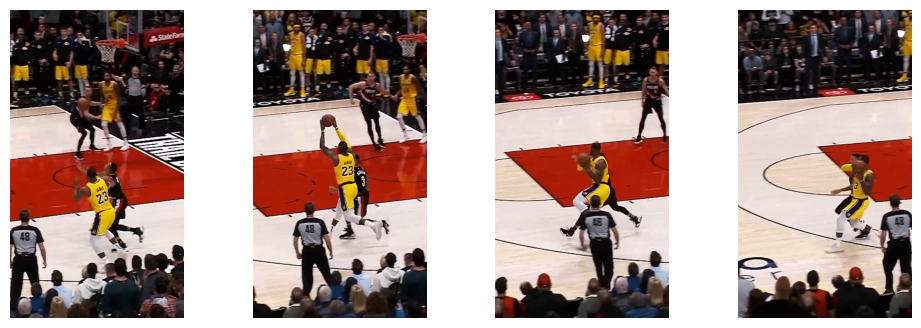

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i in range(4):

    axes[i].imshow(frames[i])

    axes[i].axis("off")

plt.show()

In [24]:
inputs = processor(
    frames,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

In [28]:
with torch.no_grad():
  outputs = model(**inputs)

logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()

from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    "google/vivit-b-16x2-kinetics400"
)

label_map = config.id2label

predicted_label = label_map[predicted_class_idx]

print(predicted_label)

print("Predicted Video Class:", predicted_label)

LABEL_161
Predicted Video Class: LABEL_161


In [26]:
print(model.config.id2label[161])

LABEL_161


In [27]:
import torch.nn.functional as F

probs = F.softmax(outputs.logits, dim=-1)

top_probs, top_idxs = torch.topk(probs, 5)

for prob, idx in zip(top_probs[0], top_idxs[0]):

    label = model.config.id2label[idx.item()]

    print(f"{label}: {prob.item():.4f}")

LABEL_161: 0.5845
LABEL_51: 0.1300
LABEL_107: 0.1297
LABEL_34: 0.0707
LABEL_150: 0.0166
